<a href="https://colab.research.google.com/github/claudio-iturra/doctoral-thesis/blob/main/002-bathymetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.signal import savgol_filter
import seaborn as sns
import pickle
#Claudio Iturra, 2025

In [2]:
import xarray as xr

file_path = '/home/cl/Google/@doctorado-sync/database/bathy-l1/gebco_2026_n-35.5_s-37.4_w-74.4_e-72.5.nc'
ds = xr.open_dataset(file_path)
print(ds)

<xarray.Dataset> Size: 839kB
Dimensions:    (lat: 456, lon: 456)
Coordinates:
  * lat        (lat) float64 4kB -37.4 -37.39 -37.39 ... -35.51 -35.51 -35.5
  * lon        (lon) float64 4kB -74.4 -74.39 -74.39 ... -72.51 -72.51 -72.5
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) float32 832kB ...
Attributes: (12/37)
    comment:                         The data in the GEBCO_2026 Grid should n...
    Conventions:                     CF-1.6, ACDD-1.3
    creator_email:                   gdacc@seabed2030.org
    creator_name:                    GEBCO through the Nippon Foundation-GEBC...
    creator_type:                    International organisation
    creator_url:                     https://www.gebco.net
    ...                              ...
    project:                         Nippon Foundation - GEBCO Seabed2030 Pro...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    source:                          The GEBCO_2026 Grid is th

In [3]:
!pip install geopy

In [13]:
#plt.pcolor(ds['lon'],ds['lat'],ds['elevation'])

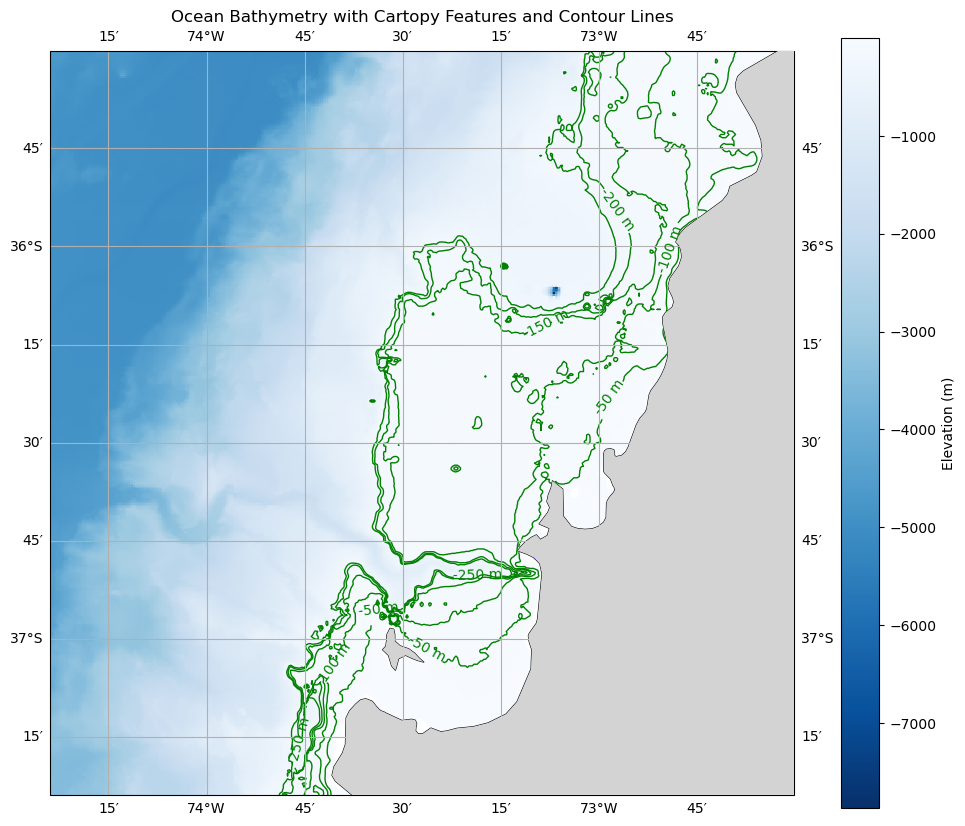

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np # Import numpy for np.arange

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree for simple lat/lon projection

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder = 3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines between 0 and 250 meters depth separated by 50 meters
# We use negative values for depth, so 250 meters depth is -250 elevation
# Contour levels must be in increasing order, so np.arange(-250, 50, 50) is used.
contour_levels = np.arange(-250, 1, 50) # From -250 to 0 (inclusive), step 50
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='green', linestyles='-', linewidths=1,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=10, fmt='%1.0f m') # Add labels to contours

# Set the extent of the map to match the data's lat/lon range
min_lon, max_lon = ds['lon'].min().item(), ds['lon'].max().item()
min_lat, max_lat = ds['lat'].min().item(), ds['lat'].max().item()
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Add gridlines and labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title('Ocean Bathymetry with Cartopy Features and Contour Lines')
plt.show()

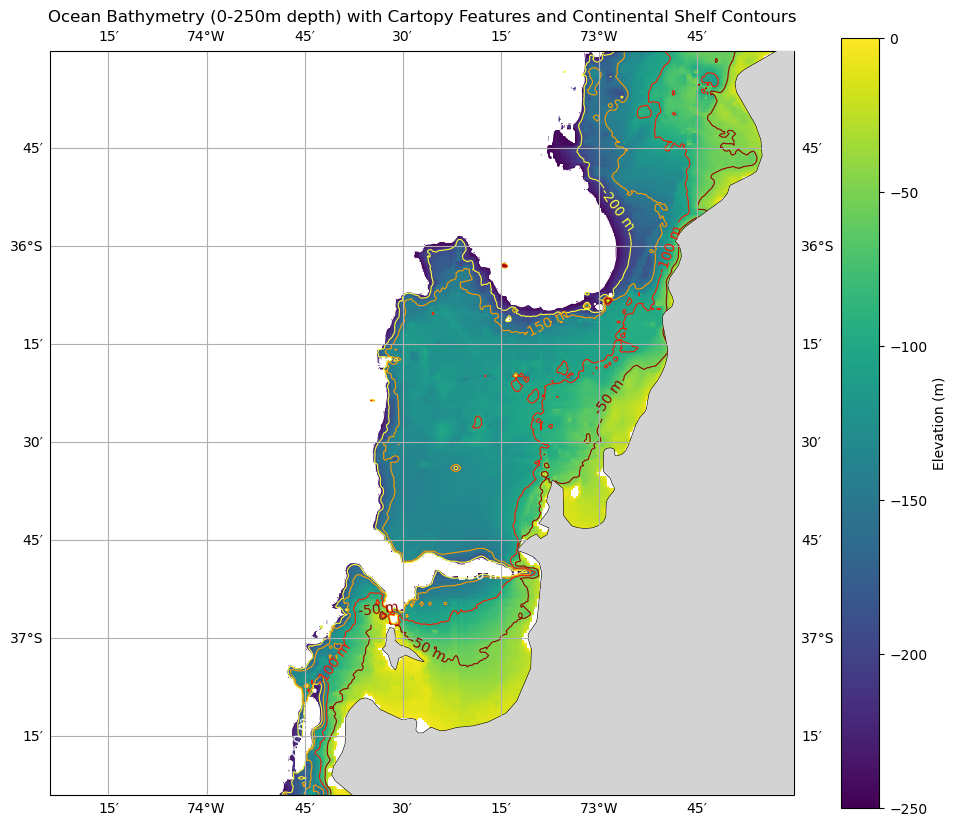

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree for simple lat/lon projection

# NEW: Mask bathymetry to only show between 0 and 250 meters depth (-250 to 0 elevation) for pcolor
shallow_bathymetry = bathymetry_data.where((bathymetry_data > -250) & (bathymetry_data < 0))

# Plot the shallow bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], shallow_bathymetry,
                   cmap='viridis', shading='auto', transform=ccrs.PlateCarree(), # Changed colormap to 'viridis'
                   vmin=-250, vmax=0) # Set explicit color range for the 0-250m depth

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder = 3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for the continental shelf (0 to -200 meters)
# We use negative values for depth, so 200 meters depth is -200 elevation
# Contour levels must be in increasing order, so [-200, 0] instead of [0, -200]
# Modified: Added more contour lines from 0 to 250 meters depth, separated by 50m, in solid line.
contour_levels = np.arange(-250, 50, 50) # From -250 to 0, step 50
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, cmap='hot_r', linestyles='-', linewidths=0.8, # Changed linestyles to '-' for solid line, adjusted linewidths, and used a colormap for different colors
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=10, fmt='%1.0f m') # Add labels to contours

# Set the extent of the map to match the data's lat/lon range
min_lon, max_lon = ds['lon'].min().item(), ds['lon'].max().item()
min_lat, max_lat = ds['lat'].min().item(), ds['lat'].max().item()
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Add gridlines and labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title('Ocean Bathymetry (0-250m depth) with Cartopy Features and Continental Shelf Contours')
plt.show()

/tmp/ipykernel_45912/2768957763.py:41: ShapelyDeprecationWarning: The 'cascaded_union()' function is deprecated. Use 'unary_union()' instead.
  merged_coastline = cascaded_union(coast_geometries) if coast_geometries else LineString() # Handle empty case
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legen

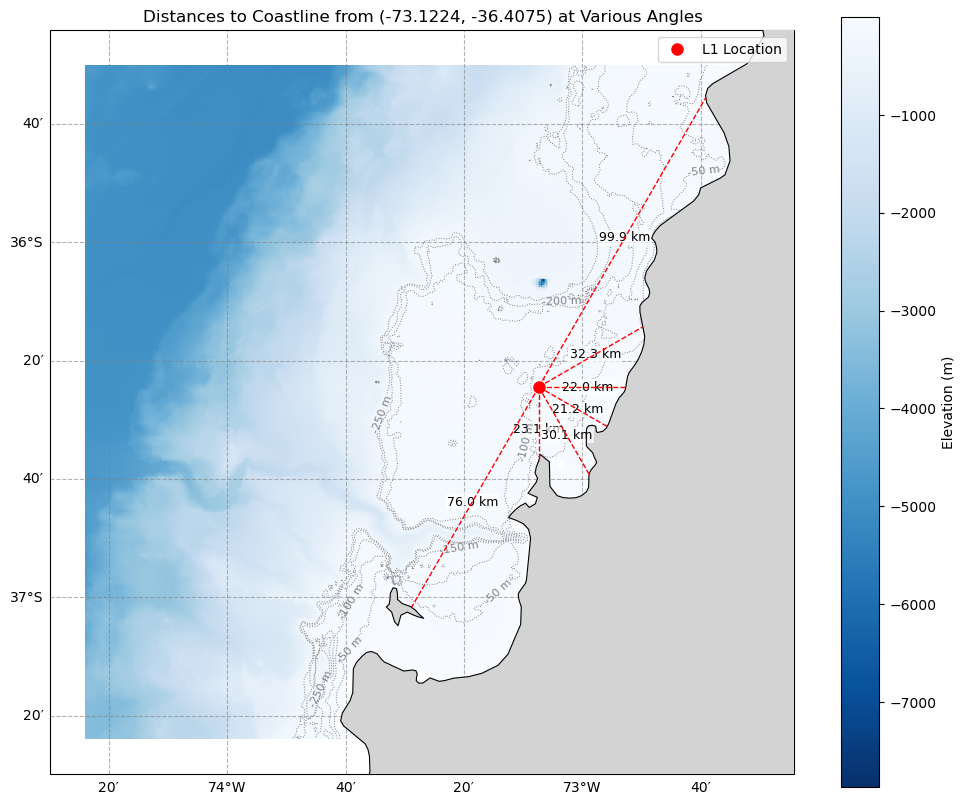

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import cascaded_union
from geopy.distance import geodesic

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point = Point(point_lon, point_lat)

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. cascaded_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = cascaded_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Define angles for rays (every 30 degrees for 12 rays)
angles_deg = np.arange(0, 360, 30)

# Determine a reasonable maximum ray length based on map extent
# This ensures rays are long enough to intersect the coastline within the plot area.
current_extent = ax.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    # Create an end point for the ray far away from the central point
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point, Point(end_lon, end_lat)])

    # Find intersection with the merged coastline
    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            # Find the point closest to the central_point among multiple intersections
            for pt in intersections.geoms:
                if central_point.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            # If intersection is a line, take the point on the line closest to the central point
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point))
        elif intersections.geom_type == 'MultiLineString':
            # If intersection is multiple lines, find the closest point among all segments
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point))
                if central_point.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point.distance(closest_intersection_pt) > 1e-6: # Ensure it's not the origin itself
        # Calculate geodesic distance in kilometers
        dist_km = geodesic((central_point.y, central_point.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Plot the line from the central point to the coastline intersection
        ax.plot([central_point.x, closest_intersection_pt.x],
                [central_point.y, closest_intersection_pt.y],
                color='red', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

        # Add distance label slightly offset from the midpoint of the line
        mid_lon = (central_point.x + closest_intersection_pt.x) / 2
        mid_lat = (central_point.y + closest_intersection_pt.y) / 2
        label_offset_factor = 0.015 # Adjust offset for label readability
        label_lon = mid_lon + label_offset_factor * np.cos(angle_rad)
        label_lat = mid_lat + label_offset_factor * np.sin(angle_rad)

        ax.text(label_lon, label_lat, f'{dist_km:.1f} km', color='black', fontsize=9, ha='center', va='center',
                transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1 # Small buffer around the data extent
ax.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title(f'Distances to Coastline from ({point_lon:.4f}, {point_lat:.4f}) at Various Angles')
ax.legend()
plt.show()

/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large a

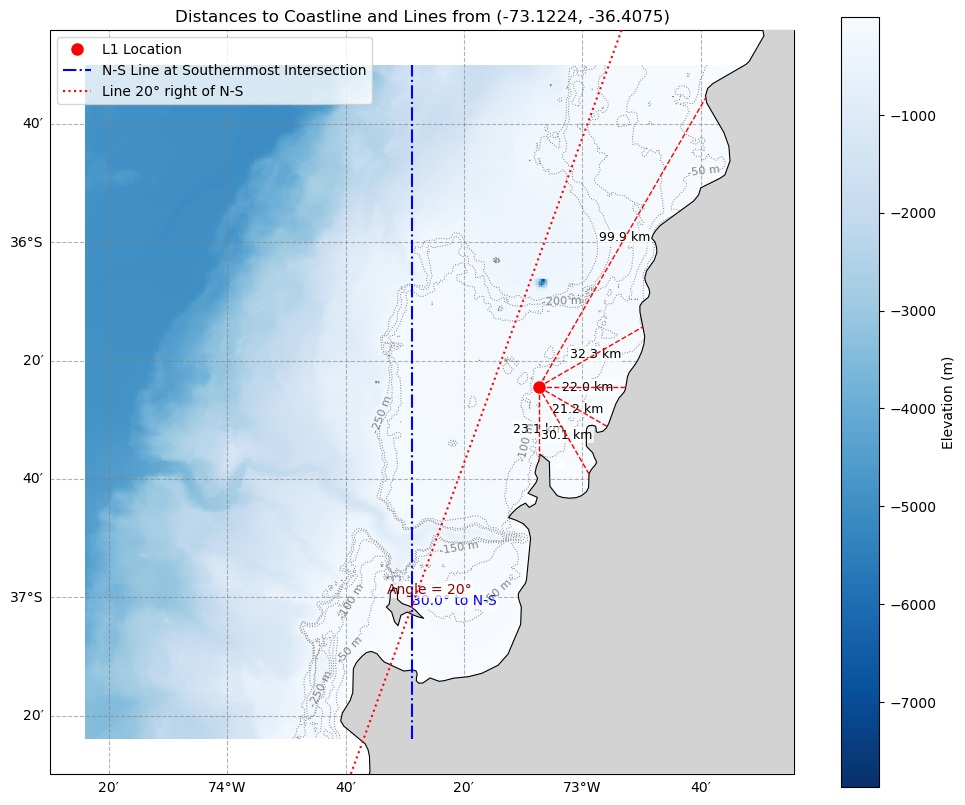

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union
from geopy.distance import geodesic
import math

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point = Point(point_lon, point_lat)

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Define angles for rays (every 30 degrees for 12 rays)
angles_deg = np.arange(0, 360, 30)

# Determine a reasonable maximum ray length based on map extent
current_extent = ax.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view


all_intersections = []

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point))
                if central_point.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point.y, central_point.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Conditionally skip plotting the 76 km line and its label
        if abs(dist_km - 76.0) > 0.5: # Use a small tolerance for float comparison
            ax.plot([central_point.x, closest_intersection_pt.x],
                    [central_point.y, closest_intersection_pt.y],
                    color='red', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

            mid_lon = (central_point.x + closest_intersection_pt.x) / 2
            mid_lat = (central_point.y + closest_intersection_pt.y) / 2
            label_offset_factor = 0.015
            label_lon = mid_lon + label_offset_factor * np.cos(angle_rad)
            label_lat = mid_lat + label_offset_factor * np.sin(angle_rad)

            ax.text(label_lon, label_lat, f'{dist_km:.1f} km', color='black', fontsize=9, ha='center', va='center',
                    transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- Code to find southernmost intersection, plot N-S line, and calculate angle ---
if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    ax.plot([south_int_lon, south_int_lon],
            [ax.get_ylim()[0], ax.get_ylim()[1]],
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - central_point.x
    delta_lat = south_int_lat - central_point.y

    # Calculate angle in degrees relative to the positive X-axis (East)
    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))

    # Convert to a positive angle in [0, 360) for easier comparison
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    # A true North-South line has directions 90 degrees (North) and 270 degrees (South).
    # We want the acute angle to the nearest North-South direction.

    # Calculate the absolute difference to 90 degrees (North)
    diff_to_north = abs(red_line_angle_deg - 90)
    # Adjust for wrap-around for the 90 degree reference (e.g., 350 vs 90 is 100 degrees, not 260)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    # Calculate the absolute difference to 270 degrees (South)
    diff_to_south = abs(red_line_angle_deg - 270)
    # Adjust for wrap-around for the 270 degree reference
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    # The acute angle to the nearest North-South line is the minimum of these two differences
    angle_diff_deg = min(diff_to_north, diff_to_south)

    ax.text(south_int_lon, south_int_lat,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # --- NEW ADDITIONS FOR THIS REQUEST ---
    # Define the angle for the new red line: 20 degrees to the right (clockwise) from the North-South line.
    # A North-South line pointing North is at 90 degrees from the positive X-axis (East).
    # 20 degrees clockwise from 90 degrees is 70 degrees from the positive X-axis.
    new_line_angle_deg = 90 - 20 # 70 degrees from East (counter-clockwise)
    new_line_angle_rad = np.radians(new_line_angle_deg)

    # The new line also passes through south_int_pt
    # To plot a line through south_int_pt with a specific angle, we need two points.
    # We can extend a certain distance in both directions from south_int_pt.
    # Using a factor of map extent for line length for better visibility
    # Increased factors to ensure the line reaches the figure frame
    line_length_factor_lon = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg
    line_length_factor_lat = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg

    # Calculate end points for the new line
    ext_lon_1 = south_int_lon + line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_1 = south_int_lat + line_length_factor_lat * np.sin(new_line_angle_rad)
    ext_lon_2 = south_int_lon - line_length_factor_lon * np.cos(new_line_angle_rad) # Opposite direction
    ext_lat_2 = south_int_lat - line_length_factor_lat * np.sin(new_line_angle_rad)

    ax.plot([ext_lon_1, ext_lon_2],
            [ext_lat_1, ext_lat_2],
            color='red', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='Line 20° right of N-S')

    # Add text for the angle between the blue and the new red line
    # This angle is explicitly 20 degrees as per the request.
    # Position the text near the southernmost intersection point, slightly offset for readability.
    text_offset_lon_angle = 0.05 * (max_lon_diff / abs(max_lon_diff))
    text_offset_lat_angle = 0.05 * (max_lat_diff / abs(max_lat_diff))

    ax.text(south_int_lon + text_offset_lon_angle, south_int_lat + text_offset_lat_angle,
            f'Angle = 20°', color='darkred', fontsize=10, ha='center', va='center',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- End of NEW ADDITIONS ---

# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1
ax.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title(f'Distances to Coastline and Lines from ({point_lon:.4f}, {point_lat:.4f})')
ax.legend()
plt.show()

/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large a

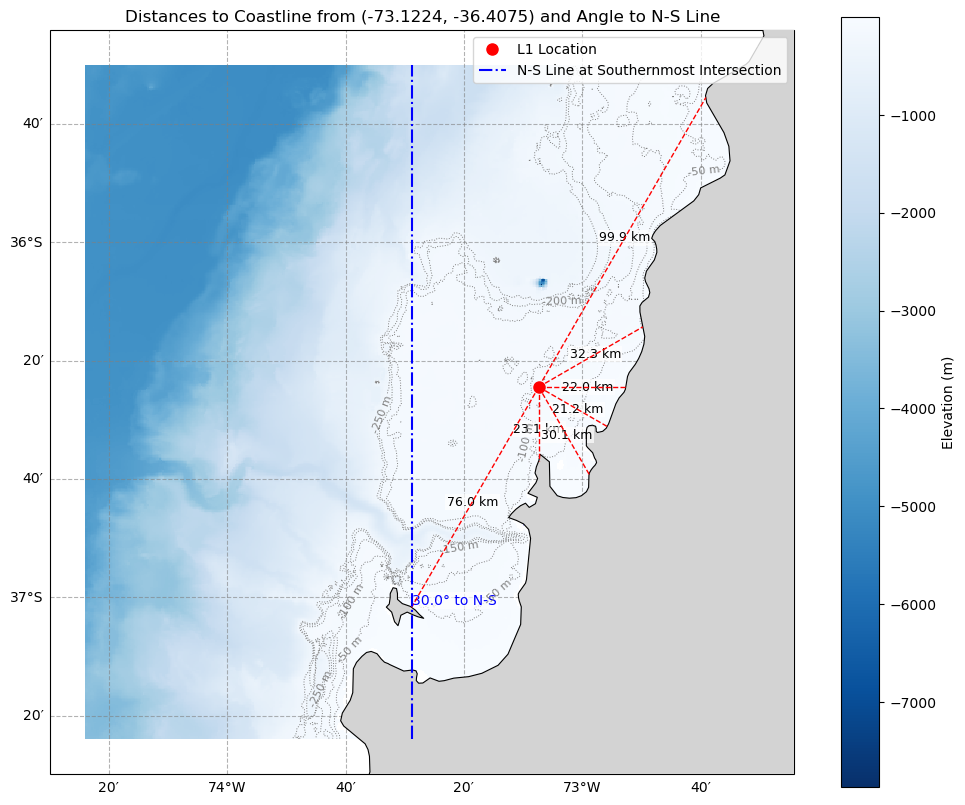

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union # Changed from cascaded_union
from geopy.distance import geodesic
import math # Import math for degrees and atan2

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point = Point(point_lon, point_lat)

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Define angles for rays (every 30 degrees for 12 rays)
angles_deg = np.arange(0, 360, 30)

# Determine a reasonable maximum ray length based on map extent
current_extent = ax.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view


all_intersections = []

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point))
                if central_point.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point.y, central_point.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        ax.plot([central_point.x, closest_intersection_pt.x],
                [central_point.y, closest_intersection_pt.y],
                color='red', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

        mid_lon = (central_point.x + closest_intersection_pt.x) / 2
        mid_lat = (central_point.y + closest_intersection_pt.y) / 2
        label_offset_factor = 0.015
        label_lon = mid_lon + label_offset_factor * np.cos(angle_rad)
        label_lat = mid_lat + label_offset_factor * np.sin(angle_rad)

        ax.text(label_lon, label_lat, f'{dist_km:.1f} km', color='black', fontsize=9, ha='center', va='center',
                transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- New code to find southernmost intersection, plot N-S line, and calculate angle ---
if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    ax.plot([south_int_lon, south_int_lon],
            [ax.get_ylim()[0], ax.get_ylim()[1]],
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - central_point.x
    delta_lat = south_int_lat - central_point.y

    # Calculate angle in degrees relative to the positive X-axis (East)
    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))

    # Convert to a positive angle in [0, 360) for easier comparison
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    # A true North-South line has directions 90 degrees (North) and 270 degrees (South).
    # We want the acute angle to the nearest North-South direction.

    # Calculate the absolute difference to 90 degrees (North)
    diff_to_north = abs(red_line_angle_deg - 90)
    # Adjust for wrap-around for the 90 degree reference (e.g., 350 vs 90 is 100 degrees, not 260)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    # Calculate the absolute difference to 270 degrees (South)
    diff_to_south = abs(red_line_angle_deg - 270)
    # Adjust for wrap-around for the 270 degree reference
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    # The acute angle to the nearest North-South line is the minimum of these two differences
    angle_diff_deg = min(diff_to_north, diff_to_south)

    ax.text(south_int_lon, south_int_lat,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- End of New Code ---

# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1
ax.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title(f'Distances to Coastline from ({point_lon:.4f}, {point_lat:.4f}) and Angle to N-S Line')
ax.legend()
plt.show()

/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/cl/anaconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large a

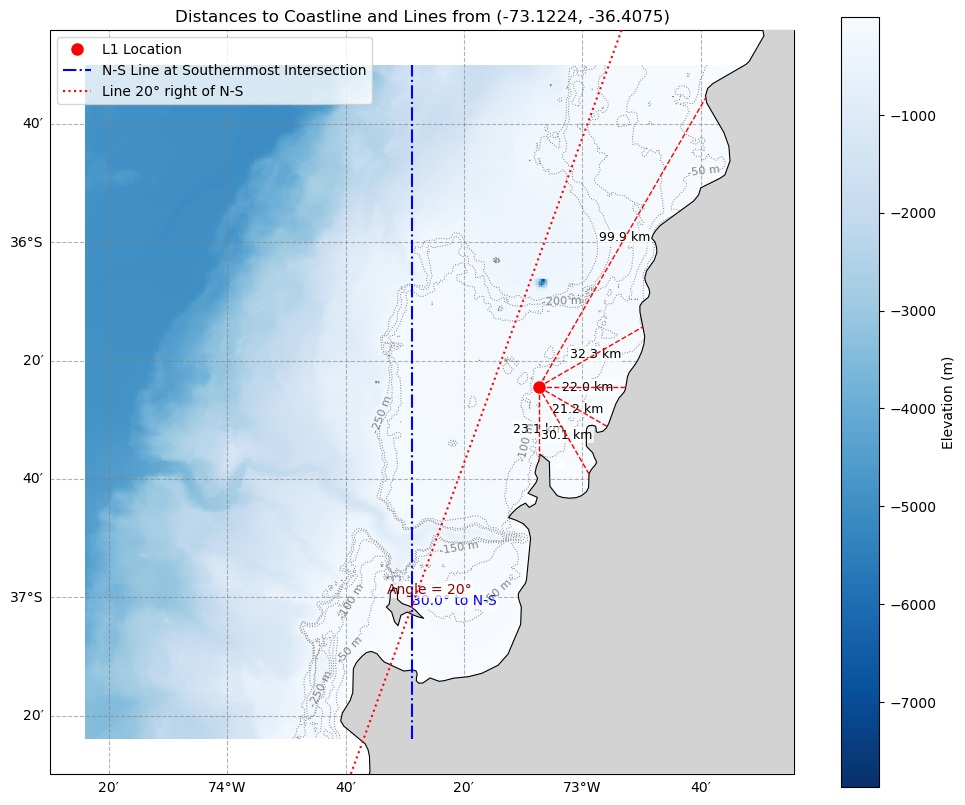

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union
from geopy.distance import geodesic
import math

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point = Point(point_lon, point_lat)

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Define angles for rays (every 30 degrees for 12 rays)
angles_deg = np.arange(0, 360, 30)

# Determine a reasonable maximum ray length based on map extent
current_extent = ax.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view


all_intersections = []

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point))
                if central_point.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point.y, central_point.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Conditionally skip plotting the 76 km line and its label
        if abs(dist_km - 76.0) > 0.5: # Use a small tolerance for float comparison
            ax.plot([central_point.x, closest_intersection_pt.x],
                    [central_point.y, closest_intersection_pt.y],
                    color='red', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

            mid_lon = (central_point.x + closest_intersection_pt.x) / 2
            mid_lat = (central_point.y + closest_intersection_pt.y) / 2
            label_offset_factor = 0.015
            label_lon = mid_lon + label_offset_factor * np.cos(angle_rad)
            label_lat = mid_lat + label_offset_factor * np.sin(angle_rad)

            ax.text(label_lon, label_lat, f'{dist_km:.1f} km', color='black', fontsize=9, ha='center', va='center',
                    transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- Code to find southernmost intersection, plot N-S line, and calculate angle ---
if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    ax.plot([south_int_lon, south_int_lon],
            [ax.get_ylim()[0], ax.get_ylim()[1]],
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - central_point.x
    delta_lat = south_int_lat - central_point.y

    # Calculate angle in degrees relative to the positive X-axis (East)
    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))

    # Convert to a positive angle in [0, 360) for easier comparison
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    # A true North-South line has directions 90 degrees (North) and 270 degrees (South).
    # We want the acute angle to the nearest North-South direction.

    # Calculate the absolute difference to 90 degrees (North)
    diff_to_north = abs(red_line_angle_deg - 90)
    # Adjust for wrap-around for the 90 degree reference (e.g., 350 vs 90 is 100 degrees, not 260)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    # Calculate the absolute difference to 270 degrees (South)
    diff_to_south = abs(red_line_angle_deg - 270)
    # Adjust for wrap-around for the 270 degree reference
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    # The acute angle to the nearest North-South line is the minimum of these two differences
    angle_diff_deg = min(diff_to_north, diff_to_south)

    ax.text(south_int_lon, south_int_lat,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # --- NEW ADDITIONS FOR THIS REQUEST ---
    # Define the angle for the new red line: 20 degrees to the right (clockwise) from the North-South line.
    # A North-South line pointing North is at 90 degrees from the positive X-axis (East).
    # 20 degrees clockwise from 90 degrees is 70 degrees from the positive X-axis.
    new_line_angle_deg = 90 - 20 # 70 degrees from East (counter-clockwise)
    new_line_angle_rad = np.radians(new_line_angle_deg)

    # The new line also passes through south_int_pt
    # To plot a line through south_int_pt with a specific angle, we need two points.
    # We can extend a certain distance in both directions from south_int_pt.
    # Using a factor of map extent for line length for better visibility
    # Increased factors to ensure the line reaches the figure frame
    line_length_factor_lon = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg
    line_length_factor_lat = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg

    # Calculate end points for the new line
    ext_lon_1 = south_int_lon + line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_1 = south_int_lat + line_length_factor_lat * np.sin(new_line_angle_rad)
    ext_lon_2 = south_int_lon - line_length_factor_lon * np.cos(new_line_angle_rad) # Opposite direction
    ext_lat_2 = south_int_lat - line_length_factor_lat * np.sin(new_line_angle_rad)

    ax.plot([ext_lon_1, ext_lon_2],
            [ext_lat_1, ext_lat_2],
            color='red', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='Line 20° right of N-S')

    # Add text for the angle between the blue and the new red line
    # This angle is explicitly 20 degrees as per the request.
    # Position the text near the southernmost intersection point, slightly offset for readability.
    text_offset_lon_angle = 0.05 * (max_lon_diff / abs(max_lon_diff))
    text_offset_lat_angle = 0.05 * (max_lat_diff / abs(max_lat_diff))

    ax.text(south_int_lon + text_offset_lon_angle, south_int_lat + text_offset_lat_angle,
            f'Angle = 20°', color='darkred', fontsize=10, ha='center', va='center',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- End of NEW ADDITIONS ---

# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1
ax.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Add a color bar
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)')

ax.set_title(f'Distances to Coastline and Lines from ({point_lon:.4f}, {point_lat:.4f})')
ax.legend()
plt.show()

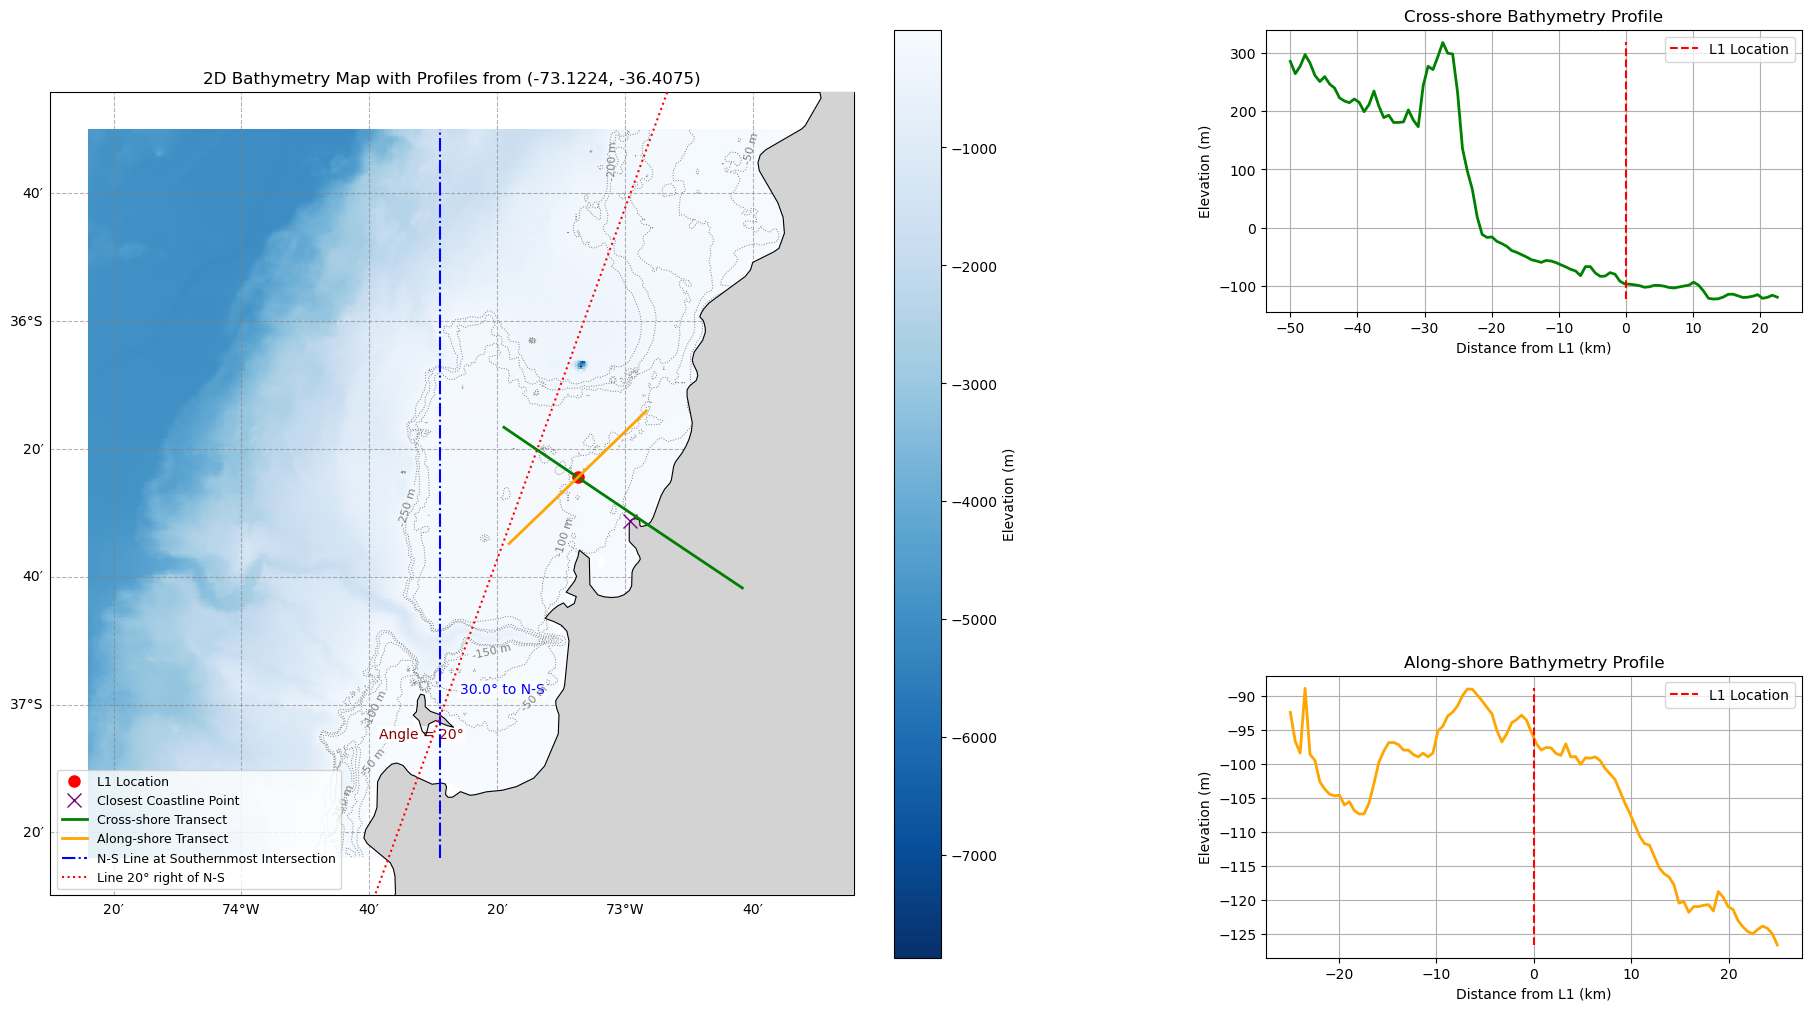

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union
from geopy.distance import geodesic
import math
import xarray as xr # Ensure xarray is imported for interpolation

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point_geom = Point(point_lon, point_lat)
central_point_geopy = (point_lat, point_lon) # For geopy (lat, lon) format

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# --- Create a figure with a grid of subplots ---
fig = plt.figure(figsize=(18, 10), constrained_layout=True) # Enable constrained_layout
gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], hspace=0.3, wspace=0.2) # 2 rows, 2 columns: map (left, spans 2 rows), profiles (right)

# --- Main Map Subplot ---
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree()) # Map spans all rows in the first column

# Plot the bathymetry data on the Cartopy axes
cf = ax_map.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax_map.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax_map.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax_map.contour(ds['lon'], ds['lat'], bathymetry_data,
                               levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                               transform=ccrs.PlateCarree())
ax_map.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax_map.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Find the closest point on the coastline to the central_point
closest_coast_pt_geom = merged_coastline.interpolate(merged_coastline.project(central_point_geom))
closest_coast_pt_lon = closest_coast_pt_geom.x
closest_coast_pt_lat = closest_coast_pt_geom.y

# Plot the closest point on the coastline (for verification)
ax_map.plot(closest_coast_pt_lon, closest_coast_pt_lat, 'x', color='purple', markersize=10, transform=ccrs.PlateCarree(), zorder=6, label='Closest Coastline Point')

# --- Define Cross-shore and Along-shore lines for profiles ---

# Cross-shore line: from central_point towards closest_coast_pt, extending beyond.
# Calculate bearing from central_point to closest_coast_pt
initial_bearing = math.degrees(math.atan2(closest_coast_pt_lon - point_lon, closest_coast_pt_lat - point_lat))

# Generate points along the cross-shore transect
dist_points_cross_km = np.linspace(-50, geodesic(central_point_geopy, (closest_coast_pt_lat, closest_coast_pt_lon)).km + 5, 100) # From 50km offshore to 5km past coastline
lon_cross, lat_cross = [], []
for dist_km in dist_points_cross_km:
    destination = geodesic(kilometers=dist_km).destination(central_point_geopy, initial_bearing + 180) # +180 to go 'offshore'
    lon_cross.append(destination.longitude)
    lat_cross.append(destination.latitude)

# Interpolate bathymetry along the cross-shore transect
bathymetry_cross_profile = ds['elevation'].interp(lon=xr.DataArray(lon_cross, dims='distance'), lat=xr.DataArray(lat_cross, dims='distance'))

# Along-shore line: perpendicular to cross-shore, through central_point
along_shore_bearing_1 = initial_bearing + 90 # Perpendicular direction
along_shore_bearing_2 = initial_bearing - 90 # Opposite perpendicular direction

dist_points_along_km = np.linspace(-25, 25, 100) # 25km each side of central_point
lon_along, lat_along = [], []
for dist_km in dist_points_along_km:
    destination = geodesic(kilometers=dist_km).destination(central_point_geopy, along_shore_bearing_1) # Use one bearing direction
    lon_along.append(destination.longitude)
    lat_along.append(destination.latitude)

# Interpolate bathymetry along the along-shore transect
bathymetry_along_profile = ds['elevation'].interp(lon=xr.DataArray(lon_along, dims='distance'), lat=xr.DataArray(lat_along, dims='distance'))

# Plot the transect lines on the map
ax_map.plot(lon_cross, lat_cross, color='green', linestyle='-', linewidth=2, transform=ccrs.PlateCarree(), zorder=7, label='Cross-shore Transect')
ax_map.plot(lon_along, lat_along, color='orange', linestyle='-', linewidth=2, transform=ccrs.PlateCarree(), zorder=7, label='Along-shore Transect')


# --- Previous code for coastline intersections and angles (kept for context, but not re-plotting rays to avoid clutter) ---
# This section of code previously calculated and plotted rays and angles.
# For now, we will skip re-plotting the individual rays to reduce clutter on the main map
# and focus on the cross-shore/along-shore profiles requested.
# If individual rays are needed again, this section can be uncommented or a new map generated.

# --- Code to find southernmost intersection, plot N-S line, and calculate angle ---
# The southernmost intersection calculation and plotting for N-S line, and 20-deg line
# is kept for calculation, but its plot will be simplified on the main map to avoid clutter
# and focus on cross-shore/along-shore.

all_intersections = []
angles_deg = np.arange(0, 360, 30)
current_extent = ax_map.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point_geom, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point_geom.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point_geom.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point_geom))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point_geom))
                if central_point_geom.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point_geom.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point_geom.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point_geom.y, central_point_geom.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Conditionally skip plotting the 76 km line and its label
        if abs(dist_km - 76.0) > 0.5: # Use a small tolerance for float comparison
            # We are no longer plotting all rays to reduce clutter, but if re-enabled, these lines would apply
            pass

if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    # Limit the line to the map's extent to avoid drawing across profile plots
    ax_map.plot([south_int_lon, south_int_lon],
            [current_extent[2], current_extent[3]], # Use map's lat extent
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - point_lon
    delta_lat = south_int_lat - point_lat

    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    diff_to_north = abs(red_line_angle_deg - 90)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    diff_to_south = abs(red_line_angle_deg - 270)
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    angle_diff_deg = min(diff_to_north, diff_to_south)

    # Only add text for angle on map, not line
    ax_map.text(south_int_lon + 0.05, south_int_lat + 0.05,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    new_line_angle_deg = 90 - 20 # 70 degrees from East (counter-clockwise)
    new_line_angle_rad = np.radians(new_line_angle_deg)

    # Plot the 20-degree line on the map, ensuring it stays within map bounds
    line_length_factor_lon = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg
    line_length_factor_lat = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg

    ext_lon_1 = south_int_lon + line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_1 = south_int_lat + line_length_factor_lat * np.sin(new_line_angle_rad)
    ext_lon_2 = south_int_lon - line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_2 = south_int_lat - line_length_factor_lat * np.sin(new_line_angle_rad)

    ax_map.plot([ext_lon_1, ext_lon_2],
            [ext_lat_1, ext_lat_2],
            color='red', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='Line 20° right of N-S')

    ax_map.text(south_int_lon - 0.05, south_int_lat - 0.05,
            f'Angle = 20°', color='darkred', fontsize=10, ha='center', va='center',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))



# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1
ax_map.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels for the map
gl_map = ax_map.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl_map.top_labels = False
gl_map.right_labels = False

# Add a color bar for the map
fig.colorbar(cf, ax=ax_map, orientation='vertical', label='Elevation (m)', pad=0.05)

ax_map.set_title(f'2D Bathymetry Map with Profiles from ({point_lon:.4f}, {point_lat:.4f})')
ax_map.legend(loc='lower left', fontsize=9)


# --- Cross-shore Profile Subplot ---
ax_cross = fig.add_subplot(gs[0, 1]) # Top right subplot
ax_cross.plot(dist_points_cross_km, bathymetry_cross_profile, color='green', linewidth=2)
ax_cross.plot([0, 0], [bathymetry_cross_profile.min(), bathymetry_cross_profile.max()], 'r--', label='L1 Location') # Mark L1 location
ax_cross.set_xlabel('Distance from L1 (km)')
ax_cross.set_ylabel('Elevation (m)')
ax_cross.set_title('Cross-shore Bathymetry Profile')
ax_cross.grid(True)
ax_cross.legend()


# --- Along-shore Profile Subplot ---
ax_along = fig.add_subplot(gs[1, 1]) # Bottom right subplot
ax_along.plot(dist_points_along_km, bathymetry_along_profile, color='orange', linewidth=2)
ax_along.plot([0, 0], [bathymetry_along_profile.min(), bathymetry_along_profile.max()], 'r--', label='L1 Location') # Mark L1 location
ax_along.set_xlabel('Distance from L1 (km)')
ax_along.set_ylabel('Elevation (m)')
ax_along.set_title('Along-shore Bathymetry Profile')
ax_along.grid(True)
ax_along.legend()


# With constrained_layout=True, tight_layout() is not strictly necessary but can be used for minor adjustments
plt.show()

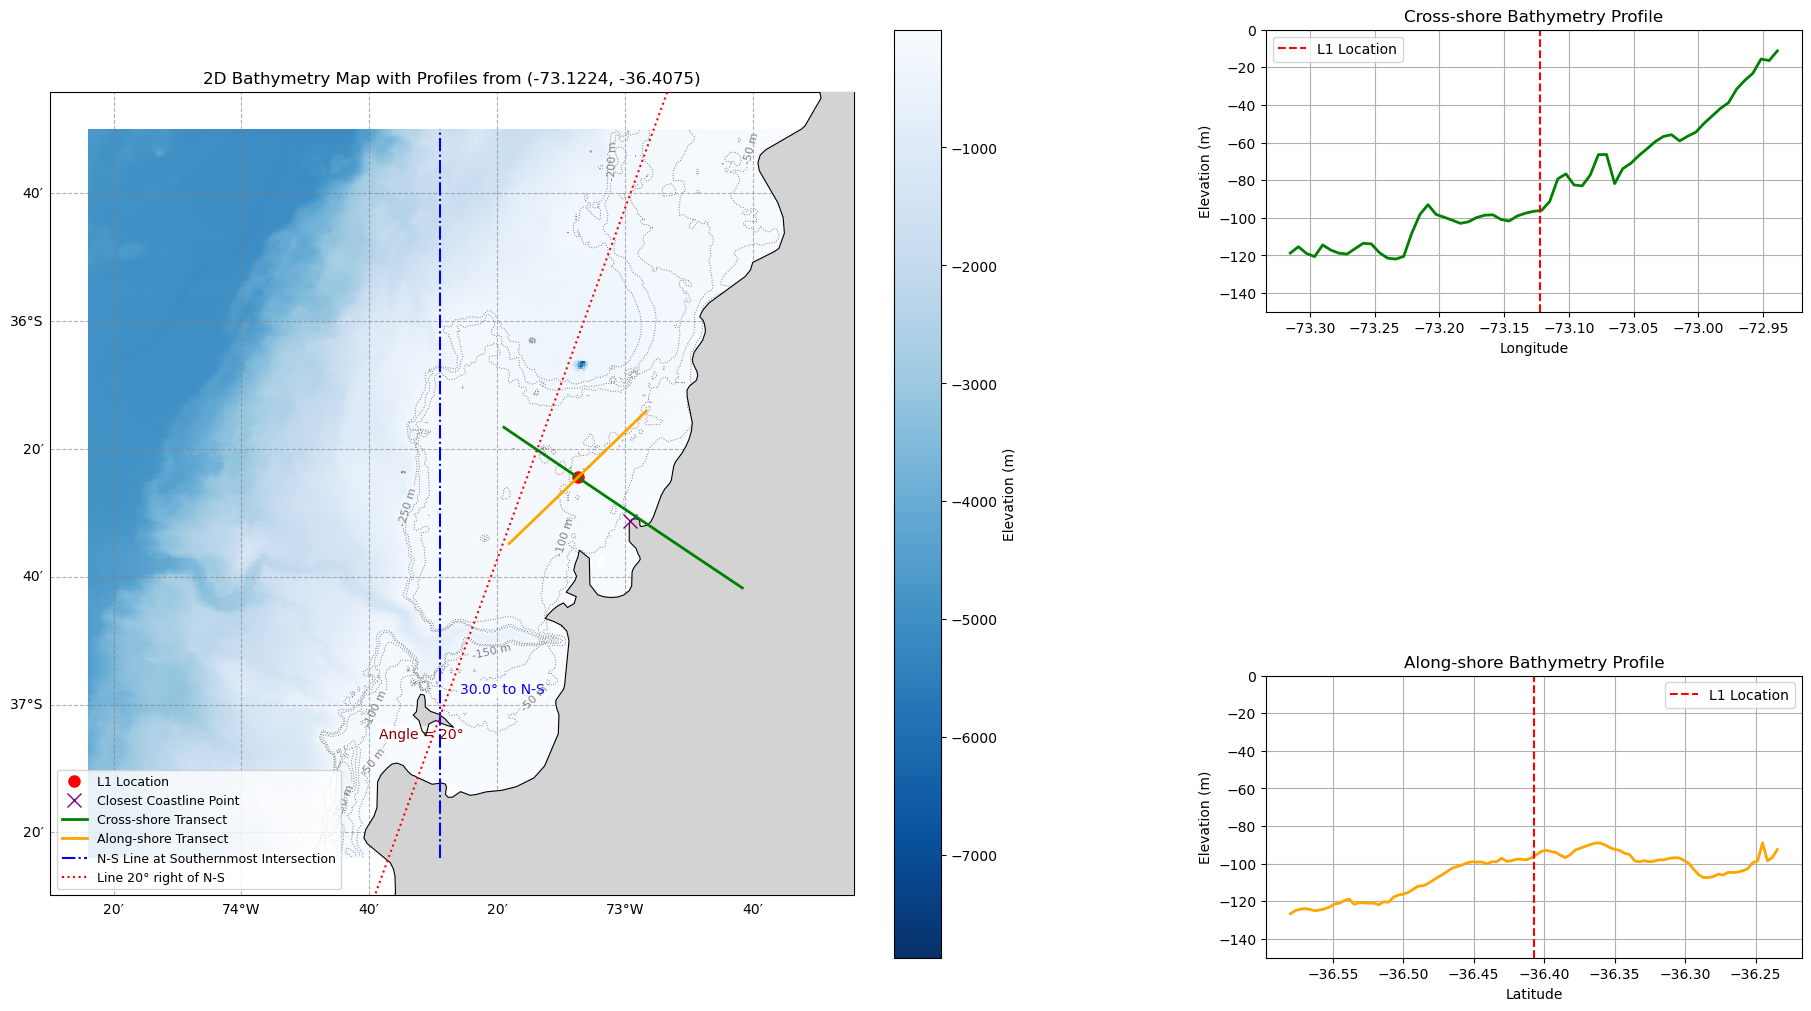

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union
from geopy.distance import geodesic
import math
import xarray as xr # Ensure xarray is imported for interpolation

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point_geom = Point(point_lon, point_lat)
central_point_geopy = (point_lat, point_lon) # For geopy (lat, lon) format

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# --- Create a figure with a grid of subplots ---
fig = plt.figure(figsize=(18, 10), constrained_layout=True) # Enable constrained_layout
gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], hspace=0.3, wspace=0.2) # 2 rows, 2 columns: map (left, spans 2 rows), profiles (right)

# --- Main Map Subplot ---
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree()) # Map spans all rows in the first column

# Plot the bathymetry data on the Cartopy axes
cf = ax_map.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax_map.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax_map.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax_map.contour(ds['lon'], ds['lat'], bathymetry_data,
                               levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                               transform=ccrs.PlateCarree())
ax_map.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax_map.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Find the closest point on the coastline to the central_point
closest_coast_pt_geom = merged_coastline.interpolate(merged_coastline.project(central_point_geom))
closest_coast_pt_lon = closest_coast_pt_geom.x
closest_coast_pt_lat = closest_coast_pt_geom.y

# Plot the closest point on the coastline (for verification)
ax_map.plot(closest_coast_pt_lon, closest_coast_pt_lat, 'x', color='purple', markersize=10, transform=ccrs.PlateCarree(), zorder=6, label='Closest Coastline Point')

# --- Define Cross-shore and Along-shore lines for profiles ---

# Cross-shore line: from central_point towards closest_coast_pt, extending beyond.
# Calculate bearing from central_point to closest_coast_pt
initial_bearing = math.degrees(math.atan2(closest_coast_pt_lon - point_lon, closest_coast_pt_lat - point_lat))

# Generate points along the cross-shore transect
dist_points_cross_km = np.linspace(-50, geodesic(central_point_geopy, (closest_coast_pt_lat, closest_coast_pt_lon)).km + 5, 100) # From 50km offshore to 5km past coastline
lon_cross, lat_cross = [], []
for dist_km in dist_points_cross_km:
    destination = geodesic(kilometers=dist_km).destination(central_point_geopy, initial_bearing + 180) # +180 to go 'offshore'
    lon_cross.append(destination.longitude)
    lat_cross.append(destination.latitude)

# Interpolate bathymetry along the cross-shore transect
bathymetry_cross_profile = ds['elevation'].interp(lon=xr.DataArray(lon_cross, dims='distance'), lat=xr.DataArray(lat_cross, dims='distance'))

# Along-shore line: perpendicular to cross-shore, through central_point
along_shore_bearing_1 = initial_bearing + 90 # Perpendicular direction
along_shore_bearing_2 = initial_bearing - 90 # Opposite perpendicular direction

dist_points_along_km = np.linspace(-25, 25, 100) # 25km each side of central_point
lon_along, lat_along = [], []
for dist_km in dist_points_along_km:
    destination = geodesic(kilometers=dist_km).destination(central_point_geopy, along_shore_bearing_1) # Use one bearing direction
    lon_along.append(destination.longitude)
    lat_along.append(destination.latitude)

# Interpolate bathymetry along the along-shore transect
bathymetry_along_profile = ds['elevation'].interp(lon=xr.DataArray(lon_along, dims='distance'), lat=xr.DataArray(lat_along, dims='distance'))

# Plot the transect lines on the map
ax_map.plot(lon_cross, lat_cross, color='green', linestyle='-', linewidth=2, transform=ccrs.PlateCarree(), zorder=7, label='Cross-shore Transect')
ax_map.plot(lon_along, lat_along, color='orange', linestyle='-', linewidth=2, transform=ccrs.PlateCarree(), zorder=7, label='Along-shore Transect')


# --- Previous code for coastline intersections and angles (kept for context, but not re-plotting rays to avoid clutter) ---
# This section of code previously calculated and plotted rays and angles.
# For now, we will skip re-plotting the individual rays to reduce clutter on the main map
# and focus on the cross-shore/along-shore profiles requested.
# If individual rays are needed again, this section can be uncommented or a new map generated.

# --- Code to find southernmost intersection, plot N-S line, and calculate angle ---
# The southernmost intersection calculation and plotting for N-S line, and 20-deg line
# is kept for calculation, but its plot will be simplified on the main map to avoid clutter
# and focus on cross-shore/along-shore.

all_intersections = []
angles_deg = np.arange(0, 360, 30)
current_extent = ax_map.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point_geom, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point_geom.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point_geom.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point_geom))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point_geom))
                if central_point_geom.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point_geom.distance(pt)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point_geom.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point_geom.y, central_point_geom.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Conditionally skip plotting the 76 km line and its label
        if abs(dist_km - 76.0) > 0.5: # Use a small tolerance for float comparison
            # We are no longer plotting all rays to reduce clutter, but if re-enabled, these lines would apply
            pass

if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    # Limit the line to the map's extent to avoid drawing across profile plots
    ax_map.plot([south_int_lon, south_int_lon],
            [current_extent[2], current_extent[3]], # Use map's lat extent
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - point_lon
    delta_lat = south_int_lat - point_lat

    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    diff_to_north = abs(red_line_angle_deg - 90)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    diff_to_south = abs(red_line_angle_deg - 270)
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    angle_diff_deg = min(diff_to_north, diff_to_south)

    # Only add text for angle on map, not line
    ax_map.text(south_int_lon + 0.05, south_int_lat + 0.05,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    new_line_angle_deg = 90 - 20 # 70 degrees from East (counter-clockwise)
    new_line_angle_rad = np.radians(new_line_angle_deg)

    # Plot the 20-degree line on the map, ensuring it stays within map bounds
    line_length_factor_lon = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg
    line_length_factor_lat = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg

    ext_lon_1 = south_int_lon + line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_1 = south_int_lat + line_length_factor_lat * np.sin(new_line_angle_rad)
    ext_lon_2 = south_int_lon - line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_2 = south_int_lat - line_length_factor_lat * np.sin(new_line_angle_rad)

    ax_map.plot([ext_lon_1, ext_lon_2],
            [ext_lat_1, ext_lat_2],
            color='red', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='Line 20° right of N-S')

    ax_map.text(south_int_lon - 0.05, south_int_lat - 0.05,
            f'Angle = 20°', color='darkred', fontsize=10, ha='center', va='center',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))



# Set the extent of the map based on data and a small buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0.1
ax_map.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels for the map
gl_map = ax_map.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl_map.top_labels = False
gl_map.right_labels = False

# Add a color bar for the map
fig.colorbar(cf, ax=ax_map, orientation='vertical', label='Elevation (m)', pad=0.05)

ax_map.set_title(f'2D Bathymetry Map with Profiles from ({point_lon:.4f}, {point_lat:.4f})')
ax_map.legend(loc='lower left', fontsize=9)


# --- Cross-shore Profile Subplot ---
ax_cross = fig.add_subplot(gs[0, 1]) # Top right subplot
ax_cross.plot(lon_cross, bathymetry_cross_profile.where(bathymetry_cross_profile < 0), color='green', linewidth=2) # Changed x-axis to lon_cross
ax_cross.plot([point_lon, point_lon], [-150, 0], 'r--', label='L1 Location') # Mark L1 location with point_lon
ax_cross.set_xlabel('Longitude') # Changed label
ax_cross.set_ylabel('Elevation (m)')
ax_cross.set_title('Cross-shore Bathymetry Profile')
ax_cross.set_ylim([-150, 0]) # Set y-axis limits
ax_cross.grid(True)
ax_cross.legend()


# --- Along-shore Profile Subplot ---
ax_along = fig.add_subplot(gs[1, 1]) # Bottom right subplot
ax_along.plot(lat_along, bathymetry_along_profile.where(bathymetry_along_profile < 0), color='orange', linewidth=2) # Changed x-axis to lat_along
ax_along.plot([point_lat, point_lat], [-150, 0], 'r--', label='L1 Location') # Mark L1 location with point_lat
ax_along.set_xlabel('Latitude') # Changed label
ax_along.set_ylabel('Elevation (m)')
ax_along.set_title('Along-shore Bathymetry Profile')
ax_along.set_ylim([-150, 0]) # Set y-axis limits
ax_along.grid(True)
ax_along.legend()


# With constrained_layout=True, tight_layout() is not strictly necessary but can be used for minor adjustments
plt.show()

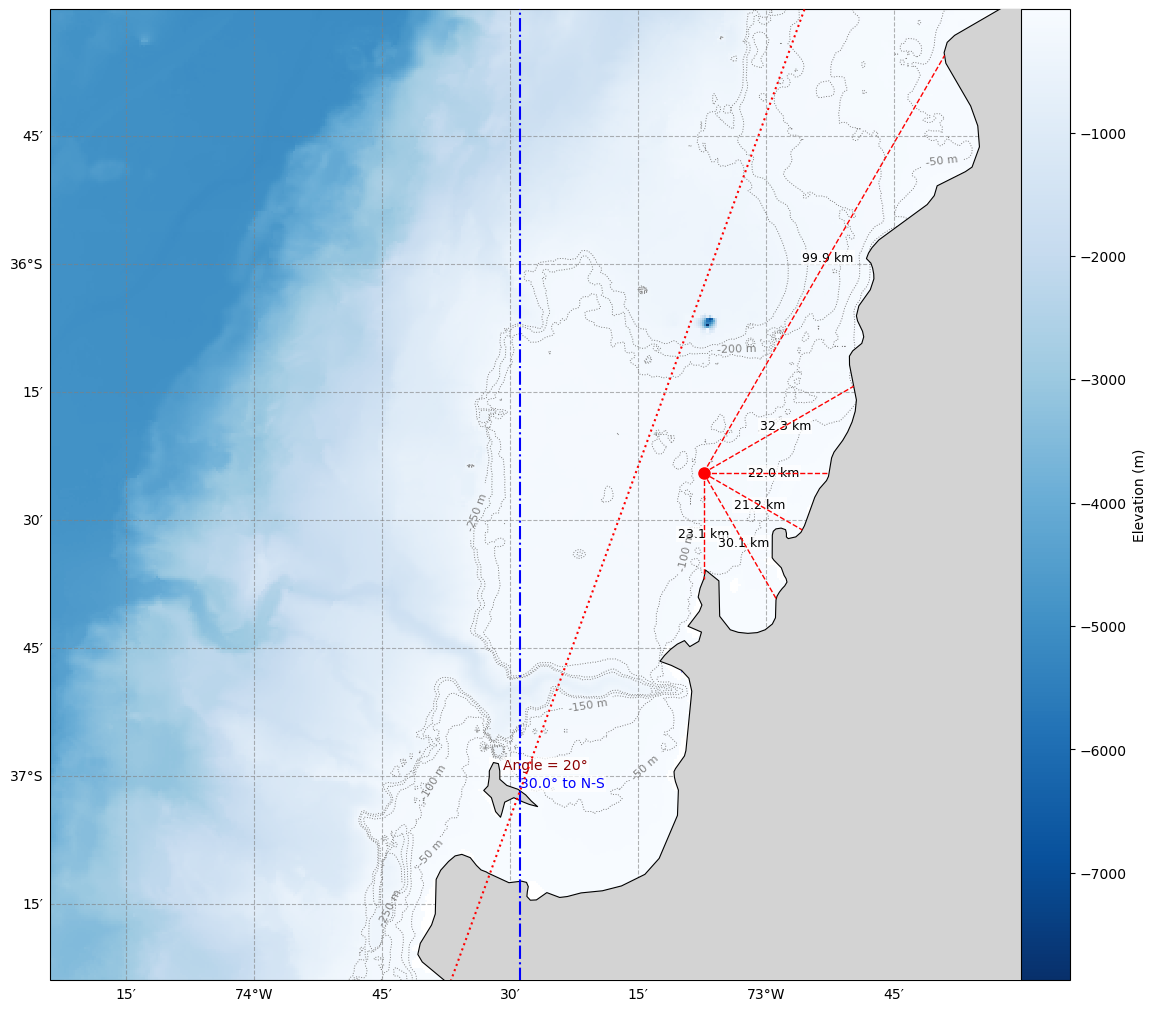

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from shapely.ops import unary_union
from geopy.distance import geodesic
import math

# Define the central point for distance calculations
point_lon = -73.1224
point_lat = -36.4075
central_point = Point(point_lon, point_lat)

# Mask out land (elevation >= 0) to only show bathymetry
bathymetry_data = ds['elevation'].where(ds['elevation'] < 0)

# Create a figure and a set of subplots with a Cartopy projection
fig = plt.figure(figsize=(12, 10), constrained_layout=True) # Added constrained_layout=True
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the bathymetry data on the Cartopy axes
cf = ax.pcolormesh(ds['lon'], ds['lat'], bathymetry_data, cmap='Blues_r', shading='auto', transform=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8, zorder=4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Add contour lines for context (reusing previous definition, made less prominent)
contour_levels = np.arange(-250, 1, 50)
contour_line = ax.contour(ds['lon'], ds['lat'], bathymetry_data,
                          levels=contour_levels, colors='grey', linestyles=':', linewidths=0.7,
                          transform=ccrs.PlateCarree())
ax.clabel(contour_line, inline=True, fontsize=8, fmt='%1.0f m')

# Plot the central dot
ax.plot(point_lon, point_lat, 'o', color='red', markersize=8, transform=ccrs.PlateCarree(), zorder=5, label='L1 Location')

# Get coastline geometries. unary_union combines them into a single (potentially multi) geometry.
coast_geometries = list(cfeature.COASTLINE.geometries())
merged_coastline = unary_union(coast_geometries) if coast_geometries else LineString() # Handle empty case

# Define angles for rays (every 30 degrees for 12 rays)
angles_deg = np.arange(0, 360, 30)

# Determine a reasonable maximum ray length based on map extent
current_extent = ax.get_extent(crs=ccrs.PlateCarree())
max_lon_diff = current_extent[1] - current_extent[0]
max_lat_diff = current_extent[3] - current_extent[2]
max_ray_length_deg = max(max_lon_diff, max_lat_diff) * 1.5 # Extend well beyond view


all_intersections = []

for angle_deg in angles_deg:
    angle_rad = np.radians(angle_deg)
    end_lon = point_lon + max_ray_length_deg * np.cos(angle_rad)
    end_lat = point_lat + max_ray_length_deg * np.sin(angle_rad)
    ray = LineString([central_point, Point(end_lon, end_lat)])

    intersections = merged_coastline.intersection(ray)

    closest_intersection_pt = None
    min_dist_to_center = np.inf

    if not intersections.is_empty:
        if intersections.geom_type == 'Point':
            closest_intersection_pt = intersections
        elif intersections.geom_type == 'MultiPoint':
            for pt in intersections.geoms:
                if central_point.distance(pt) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt)
                    closest_intersection_pt = pt
        elif intersections.geom_type == 'LineString':
            closest_intersection_pt = intersections.interpolate(intersections.project(central_point))
        elif intersections.geom_type == 'MultiLineString':
            for line_seg in intersections.geoms:
                pt_on_seg = line_seg.interpolate(line_seg.project(central_point))
                if central_point.distance(pt_on_seg) < min_dist_to_center:
                    min_dist_to_center = central_point.distance(pt_on_seg)
                    closest_intersection_pt = pt_on_seg

    if closest_intersection_pt and central_point.distance(closest_intersection_pt) > 1e-6:
        all_intersections.append({"point": closest_intersection_pt, "angle_rad": angle_rad})

        dist_km = geodesic((central_point.y, central_point.x), (closest_intersection_pt.y, closest_intersection_pt.x)).km

        # Conditionally skip plotting the 76 km line and its label
        if abs(dist_km - 76.0) > 0.5: # Use a small tolerance for float comparison
            ax.plot([central_point.x, closest_intersection_pt.x],
                    [central_point.y, closest_intersection_pt.y],
                    color='red', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

            mid_lon = (central_point.x + closest_intersection_pt.x) / 2
            mid_lat = (central_point.y + closest_intersection_pt.y) / 2
            label_offset_factor = 0.015
            label_lon = mid_lon + label_offset_factor * np.cos(angle_rad)
            label_lat = mid_lat + label_offset_factor * np.sin(angle_rad)

            ax.text(label_lon, label_lat, f'{dist_km:.1f} km', color='black', fontsize=9, ha='center', va='center',
                    transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- Code to find southernmost intersection, plot N-S line, and calculate angle ---
if all_intersections:
    # Find the southernmost intersection point
    southernmost_intersection = min(all_intersections, key=lambda x: x["point"].y)
    south_int_pt = southernmost_intersection["point"]
    south_int_lon = south_int_pt.x
    south_int_lat = south_int_pt.y

    # Plot a North-South line at the longitude of the southernmost intersection
    ax.plot([south_int_lon, south_int_lon],
            [ax.get_ylim()[0], ax.get_ylim()[1]],
            color='blue', linestyle='-.', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='N-S Line at Southernmost Intersection')

    # Calculate the angle of the red dashed line (from central_point to south_int_pt)
    delta_lon = south_int_lon - central_point.x
    delta_lat = south_int_lat - central_point.y

    # Calculate angle in degrees relative to the positive X-axis (East)
    red_line_angle_deg = math.degrees(math.atan2(delta_lat, delta_lon))

    # Convert to a positive angle in [0, 360) for easier comparison
    red_line_angle_deg = (red_line_angle_deg + 360) % 360

    # A true North-South line has directions 90 degrees (North) and 270 degrees (South).
    # We want the acute angle to the nearest North-South direction.

    # Calculate the absolute difference to 90 degrees (North)
    diff_to_north = abs(red_line_angle_deg - 90)
    # Adjust for wrap-around for the 90 degree reference (e.g., 350 vs 90 is 100 degrees, not 260)
    diff_to_north = min(diff_to_north, 360 - diff_to_north)

    # Calculate the absolute difference to 270 degrees (South)
    diff_to_south = abs(red_line_angle_deg - 270)
    # Adjust for wrap-around for the 270 degree reference
    diff_to_south = min(diff_to_south, 360 - diff_to_south)

    # The acute angle to the nearest North-South line is the minimum of these two differences
    angle_diff_deg = min(diff_to_north, diff_to_south)

    ax.text(south_int_lon, south_int_lat,
            f'{angle_diff_deg:.1f}° to N-S', color='blue', fontsize=10, ha='left', va='bottom',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # --- NEW ADDITIONS FOR THIS REQUEST ---
    # Define the angle for the new red line: 20 degrees to the right (clockwise) from the North-South line.
    # A North-South line pointing North is at 90 degrees from the positive X-axis (East).
    # 20 degrees clockwise from 90 degrees is 70 degrees from the positive X-axis.
    new_line_angle_deg = 90 - 20 # 70 degrees from East (counter-clockwise)
    new_line_angle_rad = np.radians(new_line_angle_deg)

    # The new line also passes through south_int_pt
    # To plot a line through south_int_pt with a specific angle, we need two points.
    # We can extend a certain distance in both directions from south_int_pt.
    # Using a factor of map extent for line length for better visibility
    # Increased factors to ensure the line reaches the figure frame
    line_length_factor_lon = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg
    line_length_factor_lat = max_ray_length_deg * 2 # Use a large factor based on max_ray_length_deg

    # Calculate end points for the new line
    ext_lon_1 = south_int_lon + line_length_factor_lon * np.cos(new_line_angle_rad)
    ext_lat_1 = south_int_lat + line_length_factor_lat * np.sin(new_line_angle_rad)
    ext_lon_2 = south_int_lon - line_length_factor_lon * np.cos(new_line_angle_rad) # Opposite direction
    ext_lat_2 = south_int_lat - line_length_factor_lat * np.sin(new_line_angle_rad)

    ax.plot([ext_lon_1, ext_lon_2],
            [ext_lat_1, ext_lat_2],
            color='red', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5, label='Line 20° right of N-S')

    # Add text for the angle between the blue and the new red line
    # This angle is explicitly 20 degrees as per the request.
    # Position the text near the southernmost intersection point, slightly offset for readability.
    text_offset_lon_angle = 0.05 * (max_lon_diff / abs(max_lon_diff))
    text_offset_lat_angle = 0.05 * (max_lat_diff / abs(max_lat_diff))

    ax.text(south_int_lon + text_offset_lon_angle, south_int_lat + text_offset_lat_angle,
            f'Angle = 20°', color='darkred', fontsize=10, ha='center', va='center',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- End of NEW ADDITIONS ---

# Set the extent of the map based on data with no buffer
min_lon_data, max_lon_data = ds['lon'].min().item(), ds['lon'].max().item()
min_lat_data, max_lat_data = ds['lat'].min().item(), ds['lat'].max().item()
buffer = 0 # Set buffer to 0
ax.set_extent([min_lon_data - buffer, max_lon_data + buffer, min_lat_data - buffer, max_lat_data + buffer], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Add a color bar with minimal padding
plt.colorbar(cf, ax=ax, orientation='vertical', label='Elevation (m)', pad=0.0)

# Removed ax.set_title and ax.legend() temporarily to check for white space caused by them
# ax.set_title(f'Distances to Coastline and Lines from ({point_lon:.4f}, {point_lat:.4f})')
# ax.legend()

plt.show()